# Credit Risk Analysis - Deeper EDA

This notebook continues the exploratory data analysis with:
- Binary target variable creation
- Temporal analysis
- Feature analysis (numerical & categorical)
- Default rate segmentation
- Correlation analysis

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 100)

# Load the sample
df = pd.read_csv('../data/sample_100k_stratified.csv', low_memory=False)
print(f"Data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Data loaded: 100,000 rows x 151 columns


## 2. Create Binary Target Variable

Define:
- **Default (1)**: Charged Off, Default, Late (31-120 days), Late (16-30 days)
- **Non-Default (0)**: Fully Paid, Current

In [2]:
# Define default categories
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']

# Create binary target
df['is_default'] = df['loan_status'].apply(lambda x: 1 if x in default_statuses else 0)

# Check distribution
print("Binary Target Distribution:")
print(df['is_default'].value_counts())
print("\nPercentages:")
print(df['is_default'].value_counts(normalize=True) * 100)
print(f"\n✅ Default Rate: {df['is_default'].mean()*100:.2f}%")

Binary Target Distribution:
is_default
0    86977
1    13023
Name: count, dtype: int64

Percentages:
is_default
0    86.977
1    13.023
Name: proportion, dtype: float64

✅ Default Rate: 13.02%


## 3. Temporal Analysis

### Note on Temporal Imbalance

**Concern:** The sample shows significant imbalance across years:
- Pre-2015 (2007-2014): ~20% of data (~20k loans)
- Post-2015 (2015-2018): ~80% of data (~80k loans)

**Question:** Should we use all years or only 2015-2018 for fairness?

**Decision:** I decided to include all years (2007-2018) because:
1. This is classification, not time series forecasting
2. Economic diversity (financial crisis + recovery + boom) makes the model more robust
3. More data generally improves ML models
4. We can assess if lending practices changed significantly and adjust if needed

**Action:** Analyze default rates over time to check for significant shifts in patterns.

### Parse Issue Date

In [3]:
df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_date'].dt.year

print(f"Loan Issue Date Range: {df['issue_date'].min()} to {df['issue_date'].max()}")
print(f"\nLoans by Year:\n{df['issue_year'].value_counts().sort_index()}")

Loan Issue Date Range: 2007-06-01 00:00:00 to 2018-12-01 00:00:00

Loans by Year:
issue_year
2007       31
2008       99
2009      224
2010      564
2011      980
2012     2381
2013     5910
2014    10407
2015    18597
2016    19278
2017    19546
2018    21983
Name: count, dtype: int64


In [4]:

print("Default Rate Analysis Across Time Periods:")
print("="*60)


default_rate_by_year = df.groupby('issue_year')['is_default'].mean() * 100
print("Default Rate by Year:")
print(default_rate_by_year)

df['period'] = df['issue_year'].apply(lambda x: 'Pre-2015 (2007-2014)' if x < 2015 else 'Post-2015 (2015-2018)')

period_comparison = df.groupby('period')['is_default'].agg(['mean', 'count'])
period_comparison['mean'] = period_comparison['mean'] * 100

print("" + "="*60)
print("PERIOD COMPARISON:")
print("="*60)
print(period_comparison)

# Statistical test (Chi-square)
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['period'], df['is_default'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test for Independence:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Degrees of freedom: {dof}")



Default Rate Analysis Across Time Periods:
Default Rate by Year:
issue_year
2007     9.677419
2008    13.131313
2009    13.392857
2010    11.170213
2011    16.122449
2012    16.547669
2013    15.736041
2014    17.420967
2015    18.976179
2016    16.391742
2017    10.866673
2018     3.666470
Name: is_default, dtype: float64
PERIOD COMPARISON:
                            mean  count
period                                 
Post-2015 (2015-2018)  12.113999  79404
Pre-2015 (2007-2014)   16.527481  20596
Chi-Square Test for Independence:
  Chi-square statistic: 280.8475
  P-value: 0.000000
  Degrees of freedom: 1


There is a significant statistical difference between pre-2015 and post-2015 periods. I will be considering methods to handle this in future updates.

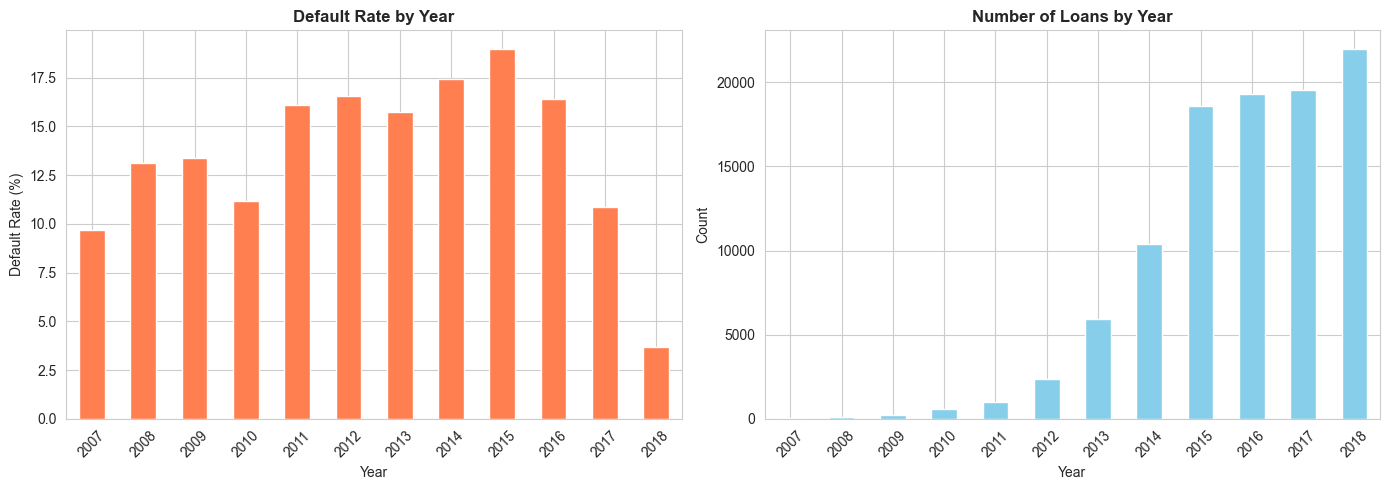


Default Rate by Year:
                 mean  count
issue_year                  
2007         9.677419     31
2008        13.131313     99
2009        13.392857    224
2010        11.170213    564
2011        16.122449    980
2012        16.547669   2381
2013        15.736041   5910
2014        17.420967  10407
2015        18.976179  18597
2016        16.391742  19278
2017        10.866673  19546
2018         3.666470  21983


In [5]:
# Default rate by year
default_by_year = df.groupby('issue_year')['is_default'].agg(['mean', 'count'])
default_by_year['mean'] = default_by_year['mean'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

default_by_year['mean'].plot(kind='bar', color='coral', ax=ax1)
ax1.set_title('Default Rate by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Default Rate (%)')
ax1.tick_params(axis='x', rotation=45)

default_by_year['count'].plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_title('Number of Loans by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nDefault Rate by Year:")
print(default_by_year)

## 4. Loan Grade Analysis

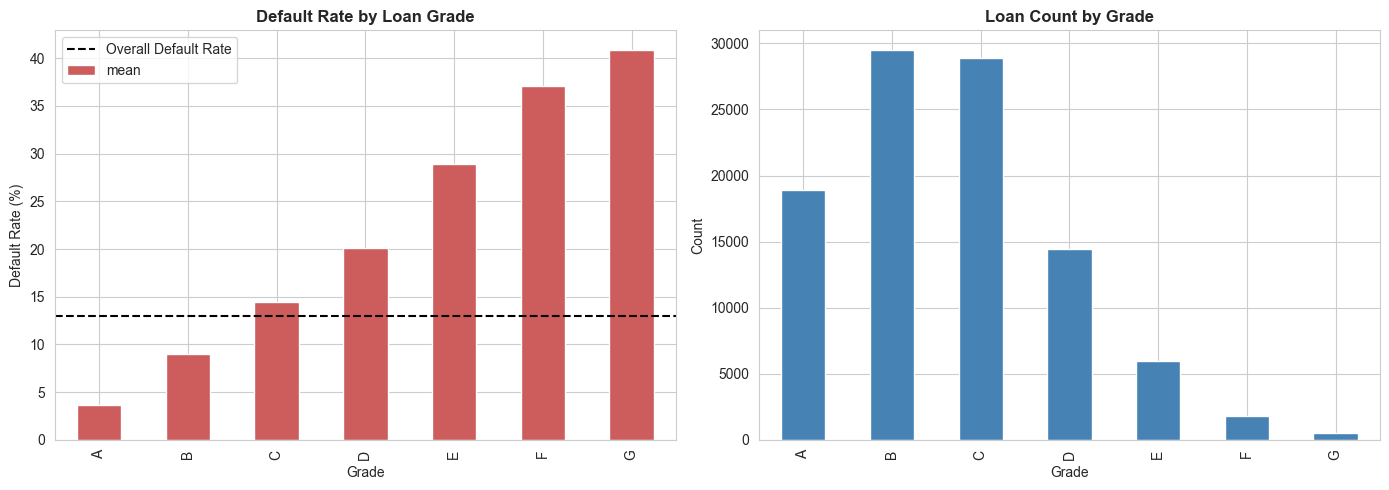


Default Rate by Grade:
            mean  count
grade                  
A       3.713711  18876
B       8.987659  29496
C      14.401581  28851
D      20.062370  14430
E      28.857381   5995
F      37.043099   1833
G      40.847784    519


In [6]:
default_by_grade = df.groupby('grade')['is_default'].agg(['mean', 'count'])
default_by_grade['mean'] = default_by_grade['mean'] * 100
default_by_grade = default_by_grade.sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

default_by_grade['mean'].plot(kind='bar', color='indianred', ax=ax1)
ax1.set_title('Default Rate by Loan Grade', fontweight='bold')
ax1.set_xlabel('Grade')
ax1.set_ylabel('Default Rate (%)')
ax1.axhline(df['is_default'].mean()*100, color='black', linestyle='--', label='Overall Default Rate')
ax1.legend()

df['grade'].value_counts().sort_index().plot(kind='bar', color='steelblue', ax=ax2)
ax2.set_title('Loan Count by Grade', fontweight='bold')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nDefault Rate by Grade:")
print(default_by_grade)

## 5. Numerical Features Analysis

In [7]:
# Key numerical features
numerical_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util']

print("Numerical Features: Defaults vs Non-Defaults\n")
for feature in numerical_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        comparison = df.groupby('is_default')[feature].describe()[['mean', '50%', 'std']].round(2)
        comparison.index = ['Non-Default', 'Default']
        print(comparison)

Numerical Features: Defaults vs Non-Defaults


loan_amnt:
                 mean      50%     std
Non-Default  14933.46  12500.0  9195.9
Default      15720.42  14400.0  8837.0

int_rate:
              mean    50%   std
Non-Default  12.72  12.12  4.68
Default      15.68  14.99  4.97

annual_inc:
                 mean      50%       std
Non-Default  78859.10  65500.0  72721.69
Default      71122.04  60000.0  90119.54

dti:
              mean    50%    std
Non-Default  18.61  17.57  14.11
Default      20.17  19.56  17.21

fico_range_low:
               mean    50%    std
Non-Default  700.02  695.0  33.52
Default      688.58  680.0  26.51

revol_util:
              mean   50%    std
Non-Default  49.90  49.7  24.72
Default      54.21  55.0  24.22


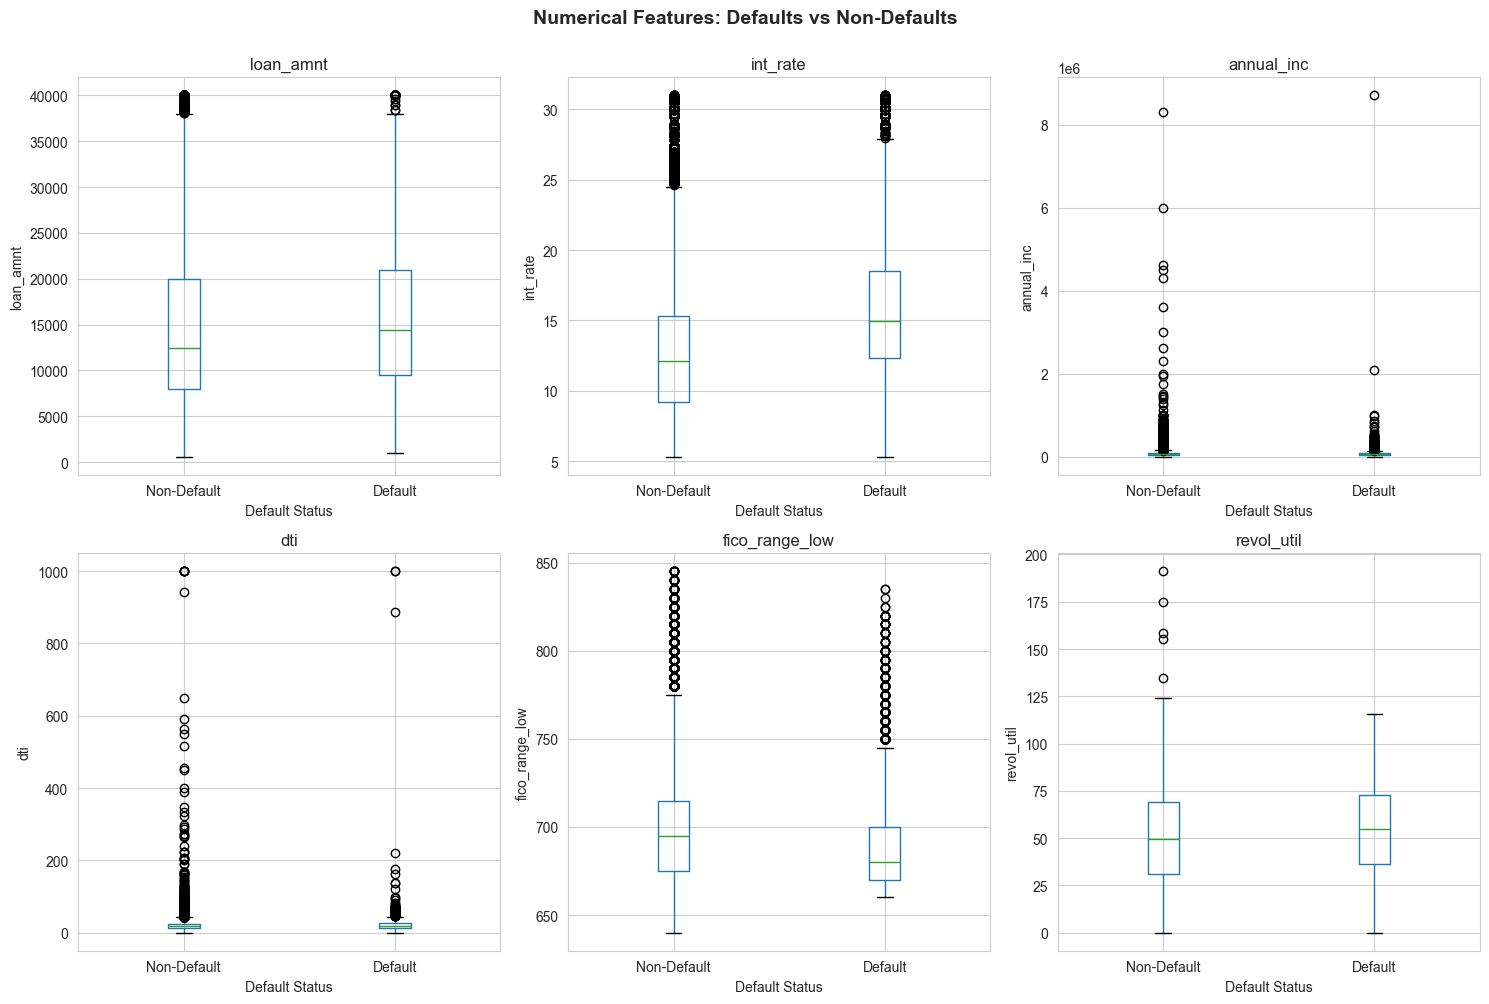

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util']):
    if feature in df.columns and idx < 6:
        df.boxplot(column=feature, by='is_default', ax=axes[idx])
        axes[idx].set_title(f'{feature}')
        axes[idx].set_xlabel('Default Status')
        axes[idx].set_ylabel(feature)
        axes[idx].set_xticklabels(['Non-Default', 'Default'])
        axes[idx].get_figure().suptitle('')

plt.suptitle('Numerical Features: Defaults vs Non-Defaults', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Categorical Features

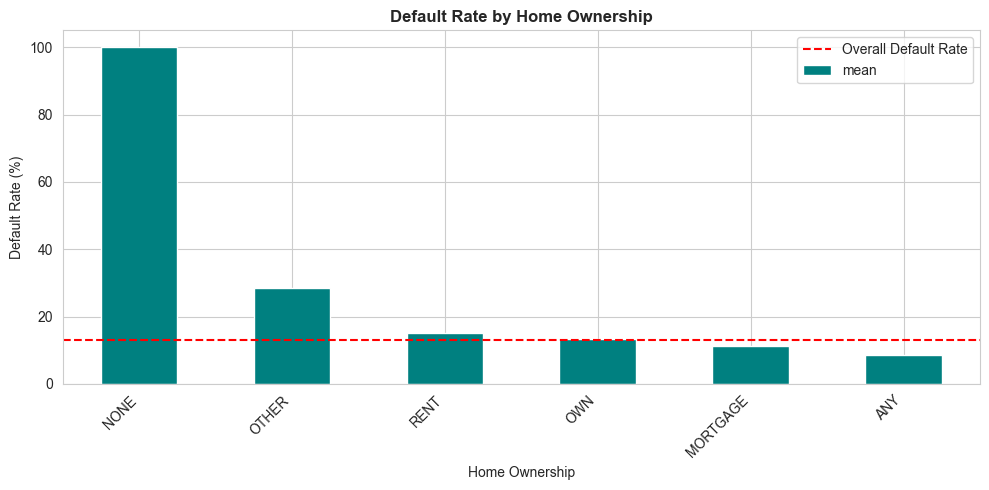

Default Rate by Home Ownership:
                      mean  count
home_ownership                   
NONE            100.000000      1
OTHER            28.571429      7
RENT             15.047614  39694
OWN              13.266494  11171
MORTGAGE         11.330481  49080
ANY               8.510638     47


In [11]:
home_default = df.groupby('home_ownership')['is_default'].agg(['mean', 'count'])
home_default['mean'] = home_default['mean'] * 100
home_default = home_default.sort_values('mean', ascending=False)

plt.figure(figsize=(10, 5))
home_default['mean'].plot(kind='bar', color='teal')
plt.title('Default Rate by Home Ownership', fontweight='bold')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['is_default'].mean()*100, color='red', linestyle='--', label='Overall Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

print("Default Rate by Home Ownership:")
print(home_default)

**Note on sparse  categories:**

Three categories have very few observations:
- : 1 loan
- : 7 loans
- : 47 loans

These are too sparse to be statistically meaningful as separate categories. In feature engineering (notebook 3), these will be grouped together into a single  category before one-hot encoding to avoid noisy dummy variables.

### Loan Purpose

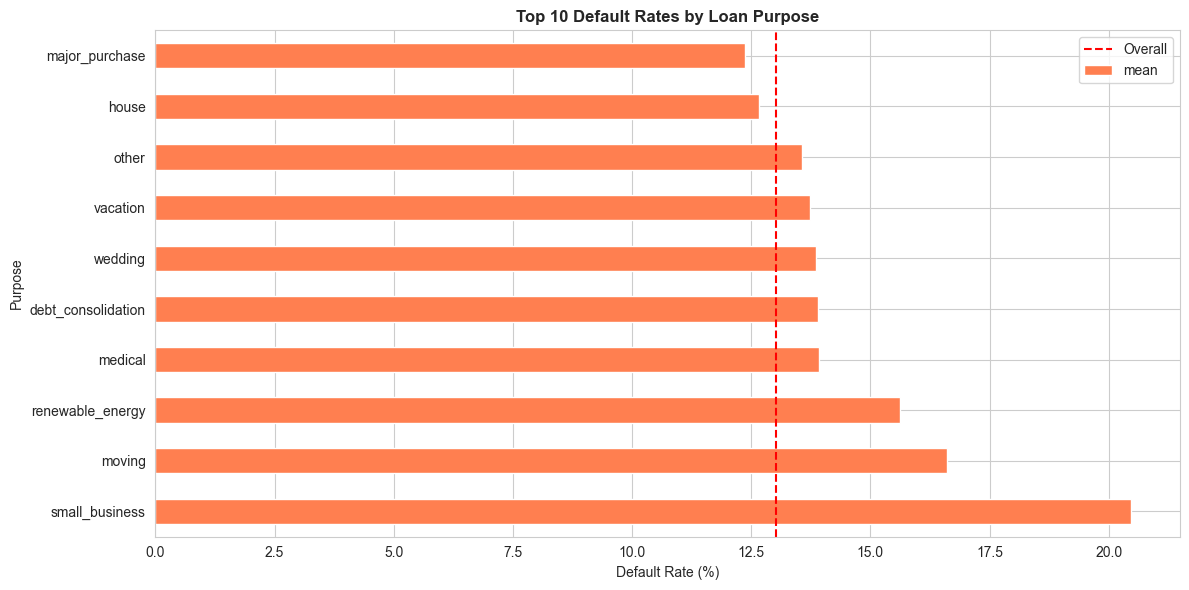


Top 10 Default Rates by Purpose:
                         mean  count
purpose                             
small_business      20.473157   1099
moving              16.617211    674
renewable_energy    15.625000     64
medical             13.926174   1192
debt_consolidation  13.910372  56634
wedding             13.861386    101
vacation            13.737075    677
other               13.576052   6180
house               12.656250    640
major_purchase      12.374429   2190


In [12]:
purpose_default = df.groupby('purpose')['is_default'].agg(['mean', 'count'])
purpose_default['mean'] = purpose_default['mean'] * 100
purpose_default = purpose_default.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
purpose_default['mean'].plot(kind='barh', color='coral')
plt.title('Top 10 Default Rates by Loan Purpose', fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Purpose')
plt.axvline(df['is_default'].mean()*100, color='red', linestyle='--', label='Overall')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 Default Rates by Purpose:")
print(purpose_default)

## 7. Drop High-Missing Features

Features with >95% missing values are not useful for modeling.
Let's identify and drop them before correlation analysis.

In [13]:

missing_pct = (df.isnull().sum() / len(df)) * 100
high_missing = missing_pct[missing_pct > 95].sort_values(ascending=False)

print(f"Features with >95% missing values: {len(high_missing)}")
print("\nTop 20 features to drop:")
print(high_missing.head(20))

# Dropping features
features_to_drop = high_missing.index.tolist()
df_clean = df.drop(columns=features_to_drop)

print(f"\n✅ Dropped {len(features_to_drop)} features")
print(f"   Dataset shape: {df.shape} → {df_clean.shape}")

# Update df to use cleaned version
df = df_clean

Features with >95% missing values: 34

Top 20 features to drop:
member_id                                     100.000
orig_projected_additional_accrued_interest     99.617
hardship_type                                  99.523
hardship_last_payment_amount                   99.523
hardship_payoff_balance_amount                 99.523
hardship_loan_status                           99.523
hardship_dpd                                   99.523
hardship_length                                99.523
payment_plan_start_date                        99.523
hardship_end_date                              99.523
hardship_start_date                            99.523
hardship_amount                                99.523
hardship_status                                99.523
hardship_reason                                99.523
deferral_term                                  99.523
settlement_term                                98.528
debt_settlement_flag_date                      98.528
settlement_percent

## 8. Correlation Analysis

In [14]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
correlations = df[numerical_cols].corr()['is_default'].sort_values(ascending=False)
correlations = correlations.drop('is_default')

print("Top 15 Features Positively Correlated with Default:")
print(correlations.head(15))
print("\nTop 15 Features Negatively Correlated with Default:")
print(correlations.tail(15))

Top 15 Features Positively Correlated with Default:
recoveries                 0.485969
collection_recovery_fee    0.457213
int_rate                   0.206742
total_rec_late_fee         0.121379
acc_open_past_24mths       0.092437
num_tl_op_past_12m         0.084230
open_rv_24m                0.083369
inq_last_6mths             0.075672
percent_bc_gt_75           0.072068
open_rv_12m                0.068956
bc_util                    0.068526
all_util                   0.068010
inq_last_12m               0.066920
open_acc_6m                0.064764
revol_util                 0.058696
Name: is_default, dtype: float64

Top 15 Features Negatively Correlated with Default:
tot_hi_cred_lim        -0.069498
total_bc_limit         -0.072345
bc_open_to_buy         -0.077111
fico_range_high        -0.116962
fico_range_low         -0.116963
id                     -0.138983
total_pymnt_inv        -0.146590
total_pymnt            -0.146594
out_prncp_inv          -0.169046
out_prncp              -0

### Visualizing top correlations

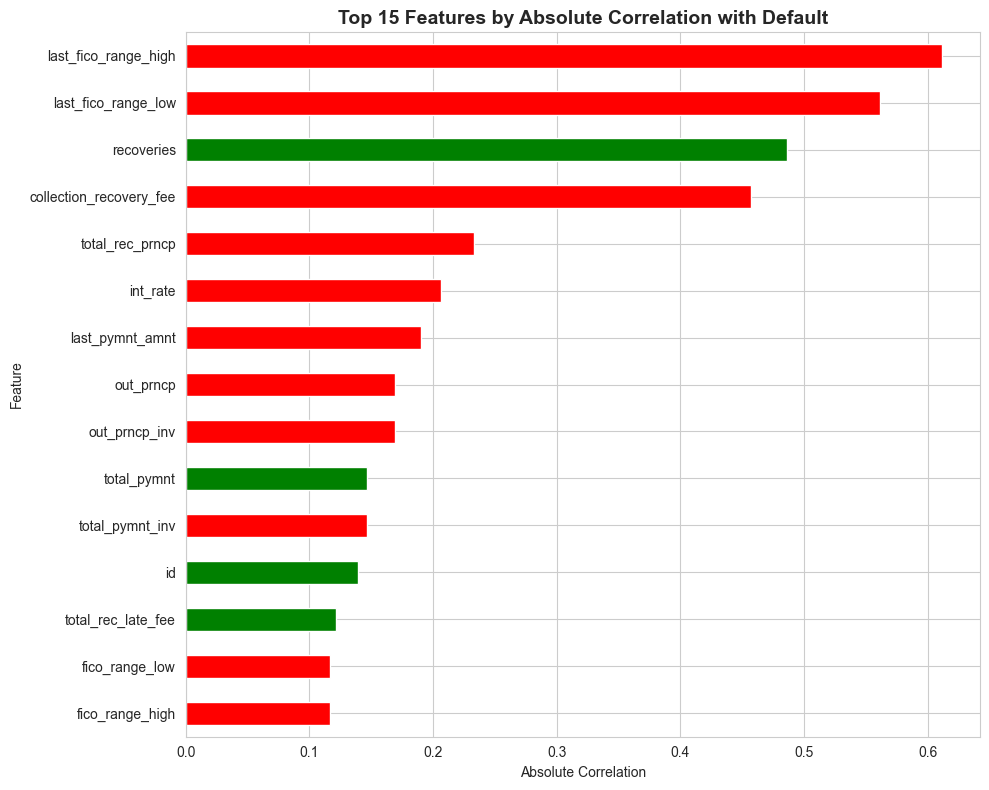

In [15]:
top_features = correlations.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
colors = ['red' if correlations[feat] < 0 else 'green' for feat in top_features.index]
top_features.sort_values().plot(kind='barh', color=colors)
plt.title('Top 15 Features by Absolute Correlation with Default', fontweight='bold', fontsize=14)
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 9. Key Insights Summary

In [16]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total loans in sample: {len(df):,}")
print(f"   - Date range: {df['issue_date'].min().strftime('%Y-%m')} to {df['issue_date'].max().strftime('%Y-%m')}")
print(f"   - Number of features: {df.shape[1]}")

print(f"\n2. DEFAULT RATE:")
print(f"   - Overall default rate: {df['is_default'].mean()*100:.2f}%")
print(f"   - Defaults: {df['is_default'].sum():,}")
print(f"   - Non-defaults: {(len(df) - df['is_default'].sum()):,}")

print(f"\n3. LOAN GRADES:")
print(f"   - Most common grade: {df['grade'].mode()[0]}")
print(f"   - Highest default rate: Grade {default_by_grade['mean'].idxmax()} ({default_by_grade['mean'].max():.2f}%)")
print(f"   - Lowest default rate: Grade {default_by_grade['mean'].idxmin()} ({default_by_grade['mean'].min():.2f}%)")

print(f"\n4. NUMERICAL FEATURES (Median values):")
print(f"   - Median loan amount: ${df['loan_amnt'].median():,.0f}")
print(f"   - Median interest rate: {df['int_rate'].median():.2f}%")
if 'annual_inc' in df.columns:
    print(f"   - Median annual income: ${df['annual_inc'].median():,.0f}")
if 'fico_range_low' in df.columns:
    print(f"   - Median FICO score: {df['fico_range_low'].median():.0f}")

print(f"\n5. TOP RISK FACTORS (Positive correlation with default):")
for i, (feature, corr) in enumerate(correlations.head(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")

print(f"\n6. TOP PROTECTIVE FACTORS (Negative correlation with default):")
for i, (feature, corr) in enumerate(correlations.tail(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")

print("\n" + "="*70)

EXPLORATORY DATA ANALYSIS - KEY FINDINGS

1. DATASET OVERVIEW:
   - Total loans in sample: 100,000
   - Date range: 2007-06 to 2018-12
   - Number of features: 121

2. DEFAULT RATE:
   - Overall default rate: 13.02%
   - Defaults: 13,023
   - Non-defaults: 86,977

3. LOAN GRADES:
   - Most common grade: B
   - Highest default rate: Grade G (40.85%)
   - Lowest default rate: Grade A (3.71%)

4. NUMERICAL FEATURES (Median values):
   - Median loan amount: $13,000
   - Median interest rate: 12.62%
   - Median annual income: $65,000
   - Median FICO score: 690

5. TOP RISK FACTORS (Positive correlation with default):
   1. recoveries: 0.4860
   2. collection_recovery_fee: 0.4572
   3. int_rate: 0.2067
   4. total_rec_late_fee: 0.1214
   5. acc_open_past_24mths: 0.0924

6. TOP PROTECTIVE FACTORS (Negative correlation with default):
   1. last_pymnt_amnt: -0.1904
   2. total_rec_prncp: -0.2332
   3. last_fico_range_low: -0.5615
   4. last_fico_range_high: -0.6115
   5. policy_code: nan

